In [64]:
import json
from pathlib import Path

# 1. Combien de samples dans le dataset source ?
with open("trajectory_dataset/trajectory_dataset.json") as f:
    ds = json.load(f)
print(f"Dataset source         : {len(ds)} samples")

# 2. Combien sont oracle_valid ?
n_valid = sum(1 for s in ds if s.get("oracle_valid", True))
print(f"  dont oracle_valid     : {n_valid}")

# 3. Combien dans le CSV ?
print(f"CSV unique sample_ids  : {df['sample_id'].nunique()}")

# 4. Lignes par variant (devrait être identique pour chaque variant)
print("\nLignes par variant :")
print(df.groupby("variant", observed=True).size())

# 5. Sample IDs manquants (présents dans le dataset mais pas dans le CSV)
ds_ids  = {s["id"] for s in ds}
csv_ids = set(df["sample_id"].unique())
missing = ds_ids - csv_ids
print(f"\nSamples manquants dans le CSV : {len(missing)}")
if missing:
    print(f"  exemples : {sorted(missing)[:10]}")

Dataset source         : 190 samples
  dont oracle_valid     : 190
CSV unique sample_ids  : 190

Lignes par variant :
variant
baseline          190
history           190
history_reason    190
cot               190
history_cot       190
dtype: int64

Samples manquants dans le CSV : 190
  exemples : ['00000', '00001', '00002', '00003', '00004', '00005', '00006', '00007', '00008', '00009']


In [53]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

# Adapte le chemin si ton notebook n'est pas dans PromptBenchmark/
RESULTS_DIR = Path("results")

df = pd.read_csv(RESULTS_DIR / "benchmark_results.csv")
with open(RESULTS_DIR / "benchmark_summary.json") as f:
    summary = json.load(f)
VARIANT_ORDER = ["baseline", "history", "history_reason", "cot", "history_cot"]
df["variant"] = pd.Categorical(df["variant"], categories=VARIANT_ORDER, ordered=True)

print(f"Samples: {df['sample_id'].nunique()}  |  Variants: {df['variant'].nunique()}")
df.head()

Samples: 190  |  Variants: 5


,sample_id,model,model_name,view,variant,env,complexity,mission,agent_carrying,optimal_actions,action_names,raw_output,predicted_action,correct,parse_failed,latency_ms
0,0,internvl3,InternVL3 8B,global,baseline,MiniGrid-DoorKey-8x8-v0,medium,use the key to open the door and then get to t...,NaN,"[0, 1]","['turn_left', 'turn_right']",2,2,False,False,1092
1,1,internvl3,InternVL3 8B,global,baseline,MiniGrid-DoorKey-5x5-v0,medium,use the key to open the door and then get to t...,NaN,[2],['forward'],3,3,False,False,237
2,2,internvl3,InternVL3 8B,global,baseline,MiniGrid-DoorKey-5x5-v0,medium,use the key to open the door and then get to t...,NaN,[1],['turn_right'],2,2,False,False,238
3,3,internvl3,InternVL3 8B,global,baseline,MiniGrid-DoorKey-16x16-v0,hard,use the key to open the door and then get to t...,NaN,"[0, 1]","['turn_left', 'turn_right']",2,2,False,False,238
4,4,internvl3,InternVL3 8B,global,baseline,MiniGrid-DoorKey-5x5-v0,medium,use the key to open the door and then get to t...,NaN,[2],['forward'],2,2,True,False,238


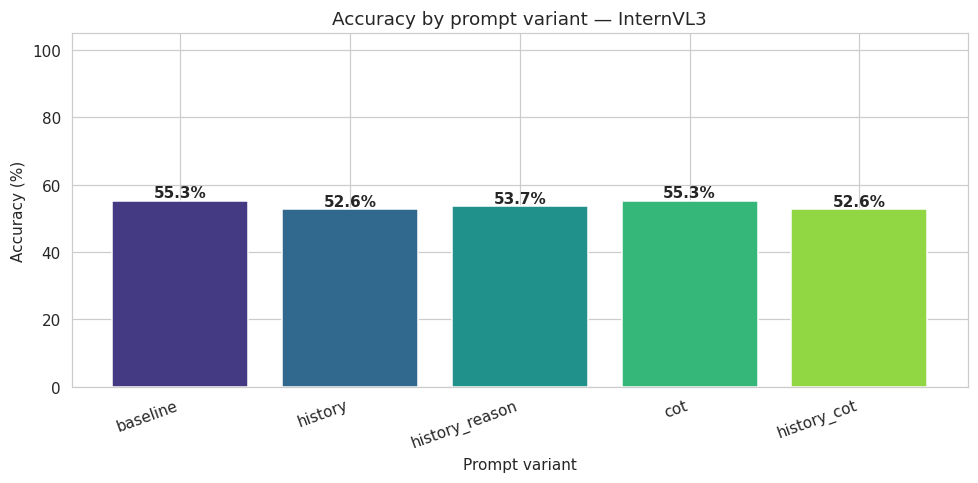

In [54]:
acc = df.groupby("variant", observed=True)["correct"].agg(["mean", "count"]).reset_index()
acc["mean"] *= 100

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(acc["variant"], acc["mean"],
              color=sns.color_palette("viridis", len(acc)))
for bar, v in zip(bars, acc["mean"]):
    ax.text(bar.get_x() + bar.get_width()/2, v + 1, f"{v:.1f}%",
            ha="center", fontsize=10, fontweight="bold")

ax.set_ylabel("Accuracy (%)")
ax.set_xlabel("Prompt variant")
ax.set_title("Accuracy by prompt variant — InternVL3")
ax.set_ylim(0, 105)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

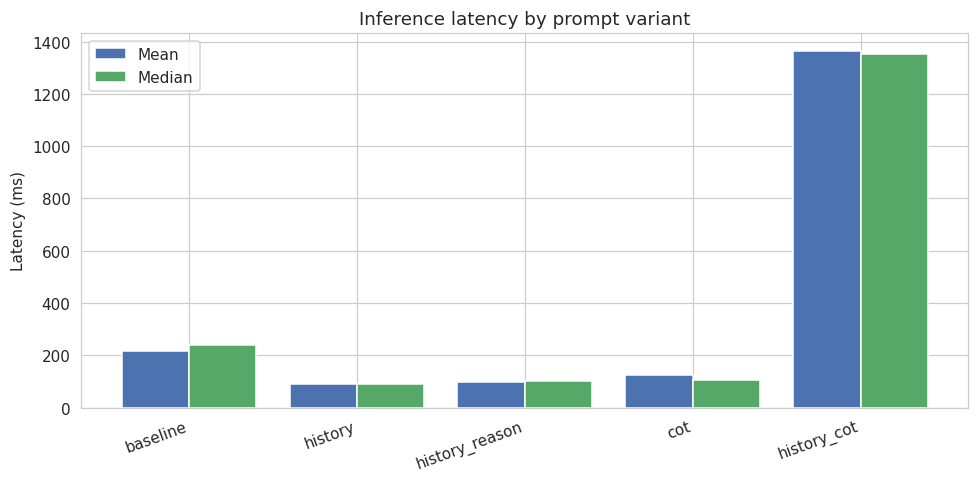

In [55]:
lat = df.groupby("variant", observed=True)["latency_ms"].agg(["mean", "median"]).reset_index()

fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(lat))
w = 0.4
ax.bar(x - w/2, lat["mean"],   w, label="Mean",   color="#4C72B0")
ax.bar(x + w/2, lat["median"], w, label="Median", color="#55A868")
ax.set_xticks(x)
ax.set_xticklabels(lat["variant"], rotation=20, ha="right")
ax.set_ylabel("Latency (ms)")
ax.set_title("Inference latency by prompt variant")
ax.legend()
plt.tight_layout()
plt.show()

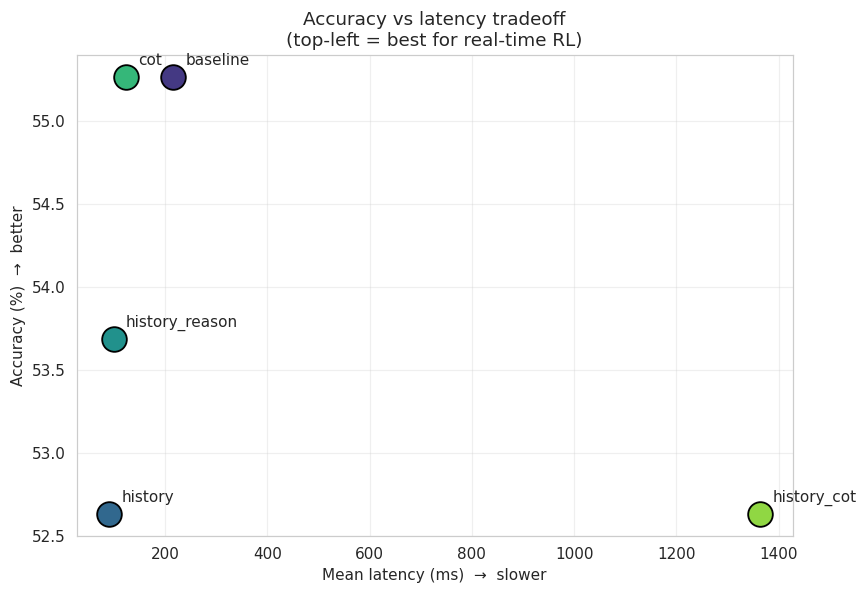

In [56]:
trade = df.groupby("variant", observed=True).agg(
    accuracy=("correct", "mean"),
    latency=("latency_ms", "mean"),
).reset_index()
trade["accuracy"] *= 100

fig, ax = plt.subplots(figsize=(8, 5.5))
colors = sns.color_palette("viridis", len(trade))
for i, row in trade.iterrows():
    ax.scatter(row["latency"], row["accuracy"], s=260, color=colors[i],
               edgecolor="black", linewidth=1.2, zorder=3)
    ax.annotate(row["variant"], (row["latency"], row["accuracy"]),
                xytext=(8, 8), textcoords="offset points", fontsize=10)

ax.set_xlabel("Mean latency (ms)  →  slower")
ax.set_ylabel("Accuracy (%)  →  better")
ax.set_title("Accuracy vs latency tradeoff\n(top-left = best for real-time RL)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

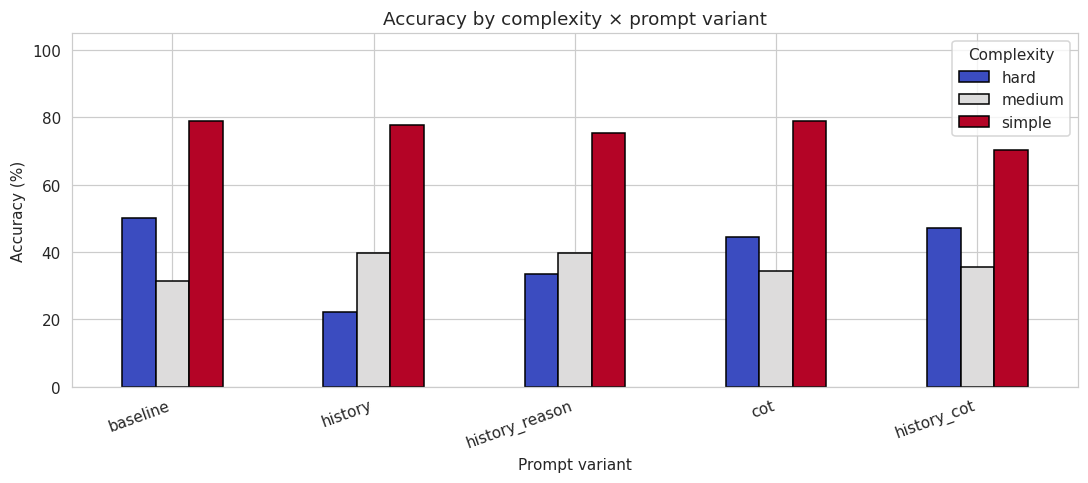

In [57]:
piv = (df.groupby(["variant", "complexity"], observed=True)["correct"]
         .mean().mul(100).unstack())

ax = piv.plot(kind="bar", figsize=(10, 4.5),
              colormap="coolwarm", edgecolor="black")
ax.set_ylabel("Accuracy (%)")
ax.set_xlabel("Prompt variant")
ax.set_title("Accuracy by complexity × prompt variant")
ax.legend(title="Complexity")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 105)
plt.tight_layout()
plt.show()

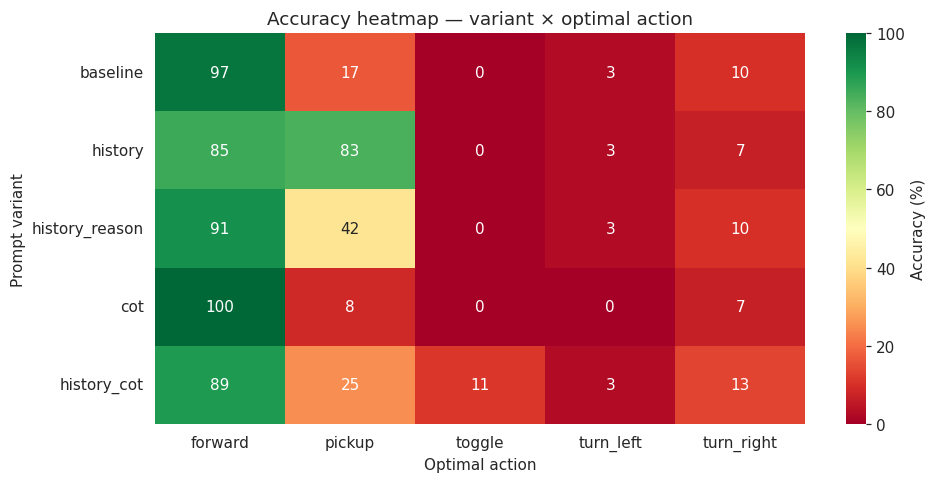

In [58]:
df_exp = df.copy()
df_exp["action_name"] = df_exp["action_names"].apply(
    lambda s: eval(s)[0] if isinstance(s, str) else s[0]
)

heat = (df_exp.groupby(["variant", "action_name"], observed=True)["correct"]
              .mean().mul(100).unstack())

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.heatmap(heat, annot=True, fmt=".0f", cmap="RdYlGn",
            vmin=0, vmax=100, cbar_kws={"label": "Accuracy (%)"}, ax=ax)
ax.set_title("Accuracy heatmap — variant × optimal action")
ax.set_xlabel("Optimal action")
ax.set_ylabel("Prompt variant")
plt.tight_layout()
plt.show()

/tmp/ipykernel_212096/3813654600.py:12: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


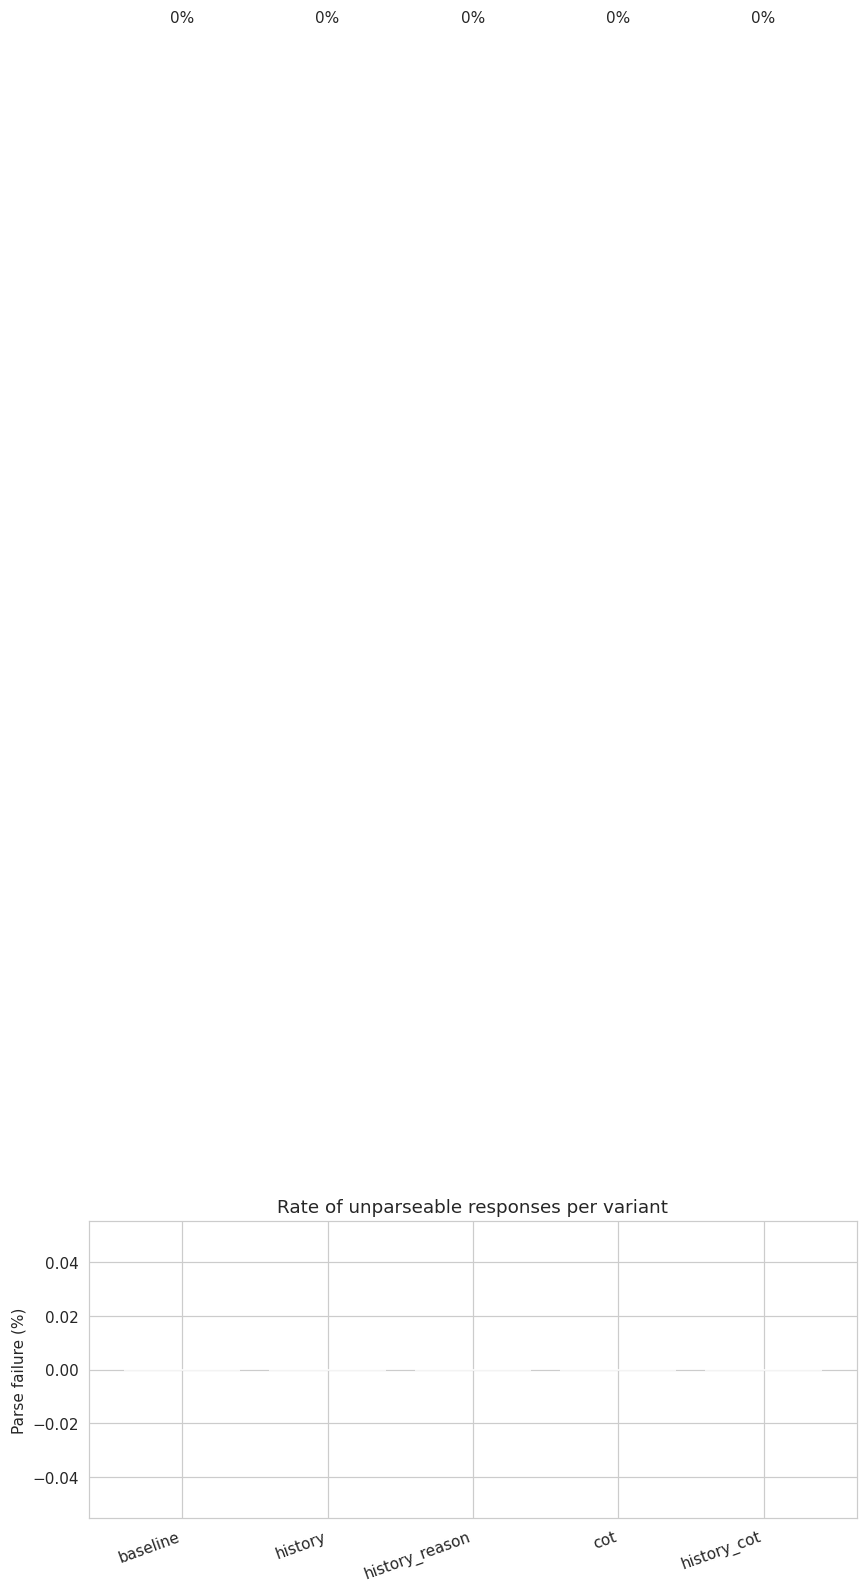


=== Variant ranking ===


,accuracy,latency_ms,parse_fail
variant,,,
baseline,55.3,215,0.0
cot,55.3,124,0.0
history_reason,53.7,99,0.0
history,52.6,91,0.0
history_cot,52.6,1364,0.0


In [59]:
fail = df.groupby("variant", observed=True)["parse_failed"].mean().mul(100)

fig, ax = plt.subplots(figsize=(9, 3.5))
bars = ax.bar(fail.index.astype(str), fail.values,
              color=sns.color_palette("Reds_r", len(fail)))
for bar, v in zip(bars, fail.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.5, f"{v:.0f}%",
            ha="center", fontsize=10)
ax.set_ylabel("Parse failure (%)")
ax.set_title("Rate of unparseable responses per variant")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

# Final ranking table
ranking = (df.groupby("variant", observed=True)
             .agg(accuracy=("correct", "mean"),
                  latency_ms=("latency_ms", "mean"),
                  parse_fail=("parse_failed", "mean"))
             .sort_values("accuracy", ascending=False))
ranking["accuracy"]   = (ranking["accuracy"]*100).round(1)
ranking["parse_fail"] = (ranking["parse_fail"]*100).round(1)
ranking["latency_ms"] = ranking["latency_ms"].round(0).astype(int)
print("\n=== Variant ranking ===")
ranking

In [60]:
print(df["predicted_action"].value_counts(normalize=True).round(2))
print()
print(df.groupby("variant")["predicted_action"].value_counts(normalize=True).round(2))

predicted_action
2    0.88
3    0.09
1    0.02
5    0.00
Name: proportion, dtype: float64

variant         predicted_action
baseline        2                   0.91
                3                   0.09
                1                   0.01
history         2                   0.78
                3                   0.21
                1                   0.01
history_reason  2                   0.87
                3                   0.09
                1                   0.03
cot             2                   0.97
                3                   0.03
history_cot     2                   0.87
                1                   0.08
                3                   0.04
                5                   0.01
Name: proportion, dtype: float64


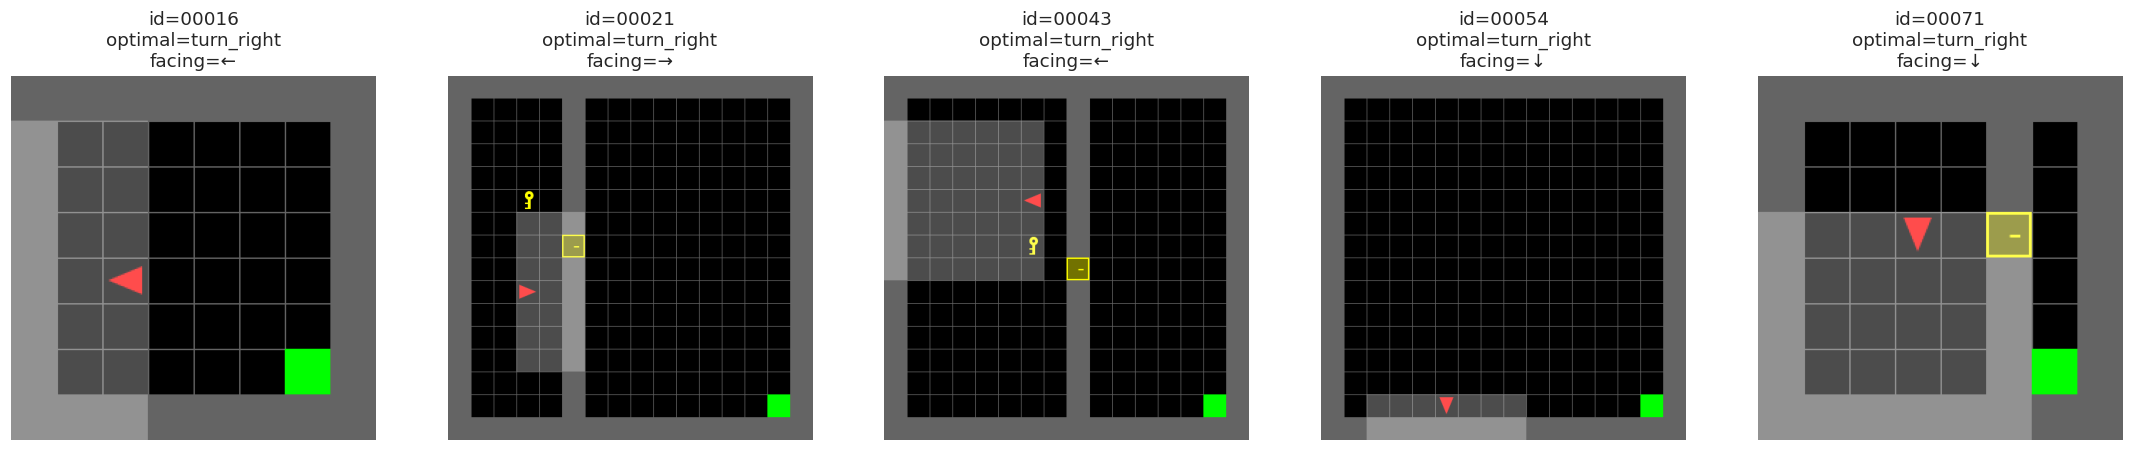

In [61]:
import matplotlib.pyplot as plt
from PIL import Image
import json

with open("trajectory_dataset/trajectory_dataset.json") as f:
    ds = json.load(f)

turn_right_samples = [s for s in ds if s["optimal_actions"] == [0]][:5]
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, s in zip(axes, turn_right_samples):
    img = Image.open("trajectory_dataset/" + s["global_image"])
    ax.imshow(img)
    ax.set_title(f"id={s['id']}\noptimal=turn_right\nfacing={s['agent_dir_str']}")
    ax.axis("off")
plt.tight_layout()
plt.show()

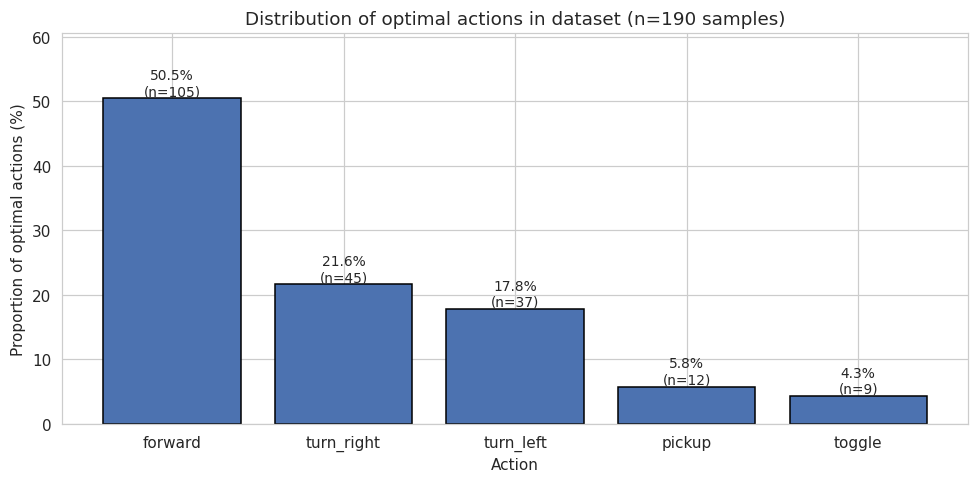


Total samples       : 190
Total optimal entries: 208  (some samples have multiple equivalent actions)


In [62]:

import json
from collections import Counter
import matplotlib.pyplot as plt
from pathlib import Path
ACTION_NAMES = {0: "turn_left", 1: "turn_right", 2: "forward",
                3: "pickup", 4: "drop", 5: "toggle"}

DATASET_PATH = Path("trajectory_dataset/trajectory_dataset.json")
with open(DATASET_PATH) as f:
    ds = json.load(f)

# Compte chaque action optimale (un sample peut en avoir plusieurs équivalentes)
counter = Counter()
for s in ds:
    for a in s.get("optimal_actions", []):
        counter[ACTION_NAMES.get(a, f"?{a}")] += 1

total = sum(counter.values())
labels = list(counter.keys())
counts = list(counter.values())
props  = [100 * c / total for c in counts]

# Tri du plus fréquent au moins fréquent
order = sorted(range(len(labels)), key=lambda i: -props[i])
labels = [labels[i] for i in order]
props  = [props[i]  for i in order]
counts = [counts[i] for i in order]

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(labels, props, color="#4C72B0", edgecolor="black")
for bar, p, c in zip(bars, props, counts):
    ax.text(bar.get_x() + bar.get_width()/2, p + 0.5,
            f"{p:.1f}%\n(n={c})", ha="center", fontsize=9)

ax.set_ylabel("Proportion of optimal actions (%)")
ax.set_xlabel("Action")
ax.set_title(f"Distribution of optimal actions in dataset (n={len(ds)} samples)")
ax.set_ylim(0, max(props) * 1.2)
plt.tight_layout()
plt.show()

print(f"\nTotal samples       : {len(ds)}")
print(f"Total optimal entries: {total}  (some samples have multiple equivalent actions)")

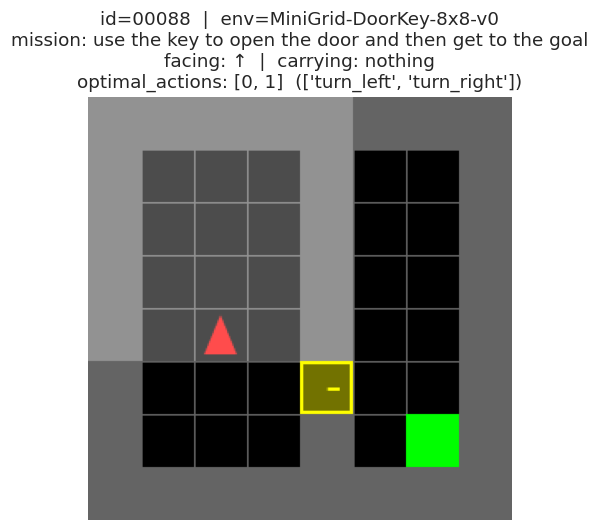

action_history: ['turn_left', 'turn_left', 'forward', 'turn_left', 'pickup']

══════════════════════════════════════════════════════════════════════════════
  VARIANT: history           (max_out=8)
══════════════════════════════════════════════════════════════════════════════
[SYSTEM]
You are an expert navigation assistant for a grid-world agent.
Your role is to analyze the agent's current visual observation and recommend the single best action to make progress toward the mission goal.

You must respond with ONLY a single integer corresponding to the action number. No explanation, no text, no punctuation — just the integer.

[USER]  <image PNG>
The image shows a TOP-DOWN view of the ENTIRE grid. You can see all objects, walls, doors, keys, and the goal. The red triangle is the agent — its pointy tip shows which direction it faces. The agent's exact facing direction is stated in text below: use the text as ground truth.

Mission: use the key to open the door and then get to the goal
Age

In [63]:
import json
import random
import sys
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

# Permet d'importer les modules du Benchmark voisin
sys.path.append("../Benchmark")
sys.path.append(".")  # pour prompt_variants.py
from utils.prompt_builder import SYSTEM_PROMPT, VIEW_CONTEXT
from prompt_variants import PROMPT_VARIANTS

DATASET_DIR  = Path("trajectory_dataset")
DATASET_PATH = DATASET_DIR / "trajectory_dataset.json"
VIEW         = "global"   # ou "partial"

with open(DATASET_PATH) as f:
    ds = json.load(f)

# Tirage aléatoire (mets une seed si tu veux reproduire)
sample = random.choice(ds)

# ── Affichage de l'image ──
img_key  = "global_image" if VIEW == "global" else "partial_image"
img_path = DATASET_DIR / sample[img_key]
img      = Image.open(img_path)

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(img)
ax.axis("off")
ax.set_title(
    f"id={sample['id']}  |  env={sample['env']}\n"
    f"mission: {sample['mission']}\n"
    f"facing: {sample.get('agent_dir_str','?')}  |  "
    f"carrying: {sample.get('agent_carrying') or 'nothing'}\n"
    f"optimal_actions: {sample.get('optimal_actions')}  "
    f"({sample.get('action_names', [])})"
)
plt.show()

print(f"action_history: {sample.get('action_history', [])}\n")

# ── Affichage des 5 prompts complets ──
v = PROMPT_VARIANTS[1]
print("═" * 78)
print(f"  VARIANT: {v['name']:<16}  (max_out={v['max_out']})")
print("═" * 78)
print("[SYSTEM]")
print(SYSTEM_PROMPT)
print()
print("[USER]  <image PNG>")
print(VIEW_CONTEXT[VIEW])
print()
print(v["fn"](sample, VIEW))
print()